#### Simple MLP to test whether MBE regularization could "resolve conflict"


Given:
- Two input distributions $p_1$ and $p_2$
- Initial model parameters $\theta_0$
- Parameter shift vector $\Delta\theta$

We define:
\begin{align}
\text{Positive samples} &: \{(x, f_{\theta_0 + \Delta\theta}(x)) \mid x \sim p_1\} \\
\text{Negative samples} &: \{(x, f_{\theta_0 - \Delta\theta}(x)) \mid x \sim p_2\}
\end{align}

Where $f_{\theta}(x)$ represents the output of the model with parameters $\theta$ given input $x$. Note that two distributions should NOT be the same. 


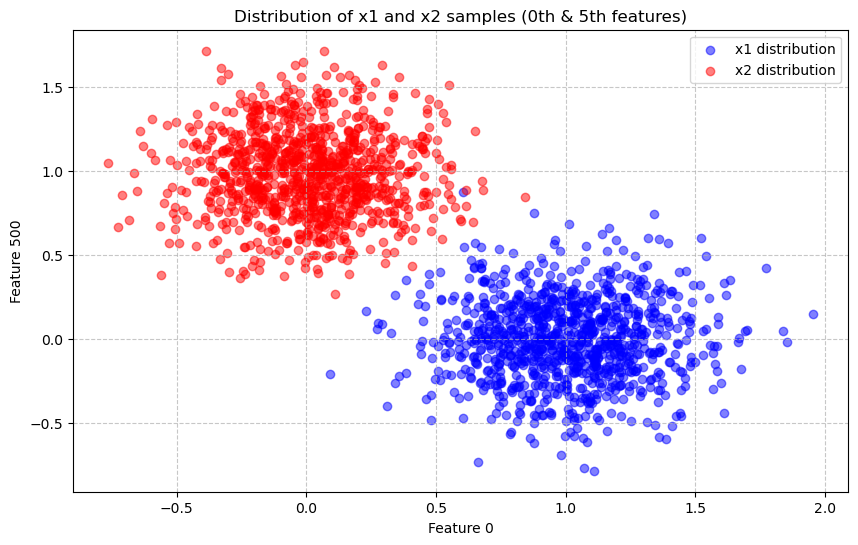

In [1]:
# initial distribution (p1 & p2)

# Define distributions p1 and p2
from src.ce_exp import sample_p1, sample_p2, plot_x1_x2

x1 = sample_p1(1000)
x2 = sample_p2(1000)
plot_x1_x2(x1, x2)


In [345]:
from src.ce_exp import * 

def decide_group_name(epoch, epochs, mod="positive"):
    if mod == "positive": 
        return "positive"
    if mod == "negative": 
        return "negative"
    if mod == "positive->negative":
        return "positive" if epoch < epochs / 2 else "negative"
    if mod == "negative->positive": 
        return "negative" if epoch < epochs / 2 else "positive"
    if mod == "interleaved": 
        return "positive" if epoch % 2 == 0 else "negative"
    if mod == "interleaved_reverse": 
        return "negative" if epoch % 2 == 0 else "positive"
    if mod == "mix": 
        return "mix" 
    if mod == "positive_mix_small_negative": 
        return "positive" if epoch % 100 != 0 else "mix"
    if mod == "negative_mix_small_positive": 
        return "negative" if epoch % 100 != 0 else "mix"

# Hyper-parameters 
# ------------------------------------------------------------
in_dim, hidden_dim, out_dim = 10, 20, 10 
data_size = 1000 
load_init = True
load_shift = True
exp_name = "exp_b2"
mod = "mix"
switch_phase = True

# Model initialization 
# ------------------------------------------------------------
mlp = SimpleModel(in_dim, hidden_dim, out_dim) # can we store a 'fixed' initial param, and load it every time we run experiment? 
# INIT_PARAMS_PATH = 'initial_mlp_params.pt'
# INIT_PARAMS_PATH = "mix_mlp_gapt_params.pt"
INIT_PARAMS_PATH = "mix_mlp_params.pt"
# INIT_PARAMS_PATH = "mix_mlp_mbe_params.pt"

if load_init: 
    mlp.load_state_dict(torch.load(INIT_PARAMS_PATH))  # Load fixed parameters
else: 
    torch.save(mlp.state_dict(), INIT_PARAMS_PATH)
    
# Load Original Parameters for comparison purpose
# ------------------------------------------------------------
mlp_original = SimpleModel(in_dim, hidden_dim, out_dim)
mlp_original.load_state_dict(torch.load(INIT_PARAMS_PATH))

# Build 'Conflicting' dataset
# ------------------------------------------------------------
PARAM_SHIFT_PATH = "param_shift.pkl"
if load_shift: 
    param_shift = load_param_shift(PARAM_SHIFT_PATH)
else: 
    param_shift = None 
# trainset, valset, param_shift = build_dataset(500, 100, mlp, in_dim, param_shift)


In [346]:
# Different Learning approaches 
# ------------------------------------------------------------
# (a). Train with P samples, then N samples 
# Initialize optimizer
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)
epochs = 1000
batch_size = 32
train_accumulation_steps = batch_size // 1
val_interval = 10
val_steps = 10

# GAPT
# ------------------------------------------------------------
from src.gapt import GatedPhaseTransition
gapt = GatedPhaseTransition(p_m=125, p_a=75, tau_spike=0.1)
# ------------------------------------------------------------


# Train with positive samples first, then negative samples
# print("Training with positive samples first, then negative samples")
print("Training with positive samples")

loss_record = defaultdict(list)
frames = [] 

# Positive samples training
for epoch in range(epochs):
    group_name = decide_group_name(epoch, epochs, mod="positive")
    if epoch % val_interval == 0: 
        val_loss, similarity_metrics = validate(mlp, mlp_original, param_shift, valset, val_steps)
        for name, value in val_loss.items(): 
            loss_record[name].append(value.item())
        for name, value in similarity_metrics.items(): 
            loss_record[name].append(value)
        log_str = build_log_str(epoch, epochs, mod, val_loss, similarity_metrics)
        print(log_str)            
        frame, specialized = neuron_specialization_frame(mlp, trainset, batch_size, group_name, epoch)
        frames.append(frame)
            
    for accum_step in range(train_accumulation_steps): 
        x_batch, y_batch = get_batch(trainset, group_name)
        optimizer.zero_grad()
        loss_dict = mlp.compute_loss(x_batch, y_batch)
        loss = gapt.step(loss_dict['l1'], 10.0 * loss_dict['mbe'], verbose=False)
        # loss = loss_dict["l1"]

        # softness = 0.1  # controls sharpness
        # soft_aux = loss_dict['mbe'].clamp(min=0.01) + softness * torch.nn.functional.softplus(
        #     (loss_dict['mbe'] - loss_dict['mbe'].clamp(min=0.01)) / softness
        # )
        # loss = loss_dict['l1'] + soft_aux

        loss.backward()
        

    optimizer.step()
    mlp.zero_grad(set_to_none=True)


Training with positive samples
 Epoch 1/1000,  | l1 positive loss: 0.0421 | mbe positive loss: 0.1233 | param shift similarity positive : 0.0000 | rep similarity positive : 0.7219 | l1 negative loss: 0.0182 | mbe negative loss: 0.1070 | param shift similarity negative : 0.0000 | rep similarity negative : 0.5501
 Epoch 11/1000,  | l1 positive loss: 0.0599 | mbe positive loss: 0.1235 | param shift similarity positive : 0.0635 | rep similarity positive : 0.7247 | l1 negative loss: 0.0746 | mbe negative loss: 0.1057 | param shift similarity negative : -0.0635 | rep similarity negative : 0.5869
 Epoch 21/1000,  | l1 positive loss: 0.0527 | mbe positive loss: 0.1021 | param shift similarity positive : 0.0529 | rep similarity positive : 0.7319 | l1 negative loss: 0.1263 | mbe negative loss: 0.1151 | param shift similarity negative : -0.0529 | rep similarity negative : 0.5559
 Epoch 31/1000,  | l1 positive loss: 0.0423 | mbe positive loss: 0.0881 | param shift similarity positive : 0.0565 | re

In [342]:
val_loss
# Obs #1. The un-trained data usually have its 'l1' and 'mbe' loss spike up together


{'l1_positive': tensor(0.0356),
 'mbe_positive': tensor(0.0149),
 'l1_negative': tensor(0.5666),
 'mbe_negative': tensor(0.0165)}

In [360]:
import pandas as pd

data = {
    "Pre-training": ["Base", "GAPT", "CE + MBE"],
    "GAPT Finetune (%)": [23.32, 14.65, -8.74],
    "CE + MBE Finetune (%)": [27.65, 36.94, 3.40]
}
df = pd.DataFrame(data).set_index("Pre-training")
print(df.to_markdown())

| Pre-training   |   GAPT Finetune (%) |   CE + MBE Finetune (%) |
|:---------------|--------------------:|------------------------:|
| Base           |               23.32 |                   27.65 |
| GAPT           |               14.65 |                   36.94 |
| CE + MBE       |               -8.74 |                    3.4  |


In [363]:
# Train w/o MBE reg -> Finetune on Pos sample 
# base
import numpy as np 
base_l1 = 0.0182
ft_base_l1 = np.array([0.48, 0.49, 0.67, 0.55, 0.50, 0.55])
ft_gapt_l1 = np.array([0.48, 0.45, 0.34, 0.45, 0.43, 0.36])
ft_ce_mbe_l1 = np.array([0.42, 0.44, 0.39, 0.39, 0.44, 0.38, 0.31])

ft_base_forget = ft_base_l1.mean() - base_l1
ft_gapt_forget = ft_gapt_l1.mean() - base_l1
ft_ce_mbe_forget = ft_ce_mbe_l1.mean() - base_l1

gapt_forget_alleviate_ratio = (ft_base_forget - ft_gapt_forget) / ft_base_forget
ce_mbe_forget_alleviate_ratio = (ft_base_forget - ft_ce_mbe_forget) / ft_base_forget

print("Base model trained w/o MBE regularization | Finetune w. MBE regularization: ")
print(f"GAPT forget alleviate ratio: {gapt_forget_alleviate_ratio:.2%}")
print(f"CE + MBE forget alleviate ratio: {ce_mbe_forget_alleviate_ratio:.2%}")

Base model trained w/o MBE regularization | Finetune w. MBE regularization: 
GAPT forget alleviate ratio: 23.32%
CE + MBE forget alleviate ratio: 27.65%


In [367]:
import numpy as np 
gapt_l1 = 0.03
ft_base_l1 = np.array([0.55, 0.41, 0.48, 0.57, 0.51, 0.29, 0.54])
ft_gapt_l1 = np.array([0.44, 0.44, 0.25, 0.38, 0.47, 0.40, 0.51])
ft_ce_mbe_l1 = np.array([0.30, 0.32, 0.31, 0.33, 0.31, 0.29, 0.33])

ft_base_forget = ft_base_l1.mean() - gapt_l1
ft_gapt_forget = ft_gapt_l1.mean() - gapt_l1
ft_ce_mbe_forget = ft_ce_mbe_l1.mean() - gapt_l1

gapt_forget_alleviate_ratio = (ft_base_forget - ft_gapt_forget) / ft_base_forget
ce_mbe_forget_alleviate_ratio = (ft_base_forget - ft_ce_mbe_forget) / ft_base_forget

print("GAPT model trained w/o MBE regularization | Finetune w. MBE regularization: ")
print(f"GAPT forget alleviate ratio: {gapt_forget_alleviate_ratio:.2%}")
print(f"CE + MBE forget alleviate ratio: {ce_mbe_forget_alleviate_ratio:.2%}")

GAPT model trained w/o MBE regularization | Finetune w. MBE regularization: 
GAPT forget alleviate ratio: 14.65%
CE + MBE forget alleviate ratio: 36.94%


In [369]:
import numpy as np 
mbe_l1 = 0.03
ft_base_l1 = np.array([0.39, 0.40, 0.46, 0.42, 0.54])
ft_gapt_l1 = np.array([0.43, 0.45, 0.42, 0.53, 0.56])
ft_ce_mbe_l1 = np.array([0.47, 0.45, 0.45, 0.44, 0.33])

ft_base_forget = ft_base_l1.mean() - mbe_l1
ft_gapt_forget = ft_gapt_l1.mean() - mbe_l1
ft_ce_mbe_forget = ft_ce_mbe_l1.mean() - mbe_l1

gapt_forget_alleviate_ratio = (ft_base_forget - ft_gapt_forget) / ft_base_forget
ce_mbe_forget_alleviate_ratio = (ft_base_forget - ft_ce_mbe_forget) / ft_base_forget

print("MBE model trained w/o MBE regularization | Finetune w. MBE regularization: ")
print(f"GAPT forget alleviate ratio: {gapt_forget_alleviate_ratio:.2%}")
print(f"CE + MBE forget alleviate ratio: {ce_mbe_forget_alleviate_ratio:.2%}")

MBE model trained w/o MBE regularization | Finetune w. MBE regularization: 
GAPT forget alleviate ratio: -8.74%
CE + MBE forget alleviate ratio: 3.40%


In [370]:
ft_base_l1.mean(), ft_gapt_l1.mean(), ft_ce_mbe_l1.mean()

(0.442, 0.47800000000000004, 0.42799999999999994)

In [ ]:
"""
Conflicting Experience Experiment - Automated Pipeline
Runs all pre-training × finetuning combinations and computes alleviation metrics.
"""
import torch
import copy
import numpy as np
import pandas as pd
from collections import defaultdict
from src.ce_exp import (
    SimpleModel, build_dataset, get_batch, validate, 
    load_param_shift, save_param_shift
)
from src.gapt import GatedPhaseTransition

# ============================================================
# Config
# ============================================================
CFG = {
    "in_dim": 10, "hidden_dim": 20, "out_dim": 10,
    "pretrain_epochs": 1000, "finetune_epochs": 1000,
    "batch_size": 32, "lr": 0.01,
    "n_runs": 6,  # Number of runs per combination
    "val_steps": 10,
    "gapt_pm": 125, "gapt_pa": 75, "gapt_tau": 0.1,
    "mbe_weight": 10.0, "mbe_softness": 0.1,
}

# ============================================================
# Training Methods
# ============================================================
def compute_loss_base(loss_dict, gapt=None):
    """Standard L_NLL only"""
    return loss_dict['l1']

def compute_loss_gapt(loss_dict, gapt):
    """GAPT: gated phase transition between L1 and MBE"""
    return gapt.step(loss_dict['l1'], CFG['mbe_weight'] * loss_dict['mbe'], verbose=False)

def compute_loss_mbe(loss_dict, gapt=None):
    """CE + soft MBE regularization"""
    soft_aux = loss_dict['mbe'].clamp(min=0.01) + CFG['mbe_softness'] * torch.nn.functional.softplus(
        (loss_dict['mbe'] - loss_dict['mbe'].clamp(min=0.01)) / CFG['mbe_softness']
    )
    return loss_dict['l1'] + soft_aux

METHODS = {
    "base": compute_loss_base,
    "gapt": compute_loss_gapt,
    "mbe": compute_loss_mbe,
}

# ============================================================
# Core Training Loop
# ============================================================
def train_phase(model, trainset, valset, mlp_original, param_shift, 
                method_name, epochs, train_mode="mix"):
    """Single training phase (pretrain or finetune)"""
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
    gapt = GatedPhaseTransition(p_m=CFG['gapt_pm'], p_a=CFG['gapt_pa'], tau_spike=CFG['gapt_tau'])
    loss_fn = METHODS[method_name]
    
    for epoch in range(epochs):
        x_batch, y_batch = get_batch(trainset, train_mode, CFG['batch_size'])
        optimizer.zero_grad()
        loss_dict = model.compute_loss(x_batch, y_batch)
        loss = loss_fn(loss_dict, gapt)
        loss.backward()
        optimizer.step()
    
    # Final validation
    val_loss, _ = validate(model, mlp_original, param_shift, valset, CFG['val_steps'])
    return val_loss

# ============================================================
# Single Experiment Run
# ============================================================
def run_single_experiment(pretrain_method, finetune_method, trainset, valset, 
                          mlp_original, param_shift):
    """Run one pretrain -> finetune experiment, return l1_neg after finetune"""
    # Fresh model copy
    model = copy.deepcopy(mlp_original)
    
    # Phase 1: Pretrain on mixed data
    _ = train_phase(model, trainset, valset, mlp_original, param_shift,
                    pretrain_method, CFG['pretrain_epochs'], train_mode="mix")
    
    # Phase 2: Finetune on positive only
    val_loss = train_phase(model, trainset, valset, mlp_original, param_shift,
                           finetune_method, CFG['finetune_epochs'], train_mode="positive")
    
    return {
        'l1_pos': val_loss['l1_positive'].item(),
        'l1_neg': val_loss['l1_negative'].item(),
        'mbe_pos': val_loss['mbe_positive'].item(),
        'mbe_neg': val_loss['mbe_negative'].item(),
    }

# ============================================================
# Full Experiment Suite
# ============================================================
def run_full_experiment():
    """Run all combinations with multiple seeds"""
    # Setup
    mlp_base = SimpleModel(CFG['in_dim'], CFG['hidden_dim'], CFG['out_dim'])
    param_shift = load_param_shift("param_shift.pkl")
    trainset, valset, param_shift = build_dataset(500, 100, mlp_base, CFG['in_dim'], param_shift)
    
    # Results storage: results[pretrain][finetune] = list of l1_neg values
    results = defaultdict(lambda: defaultdict(list))
    
    pretrain_methods = ['base', 'gapt', 'mbe']
    finetune_methods = ['base', 'gapt', 'mbe']
    
    total = len(pretrain_methods) * len(finetune_methods) * CFG['n_runs']
    run_count = 0
    
    for pretrain in pretrain_methods:
        for finetune in finetune_methods:
            for run_idx in range(CFG['n_runs']):
                run_count += 1
                print(f"[{run_count}/{total}] Pretrain: {pretrain} | Finetune: {finetune} | Run: {run_idx+1}")
                
                # Reset base model each run (or use fixed seed)
                torch.manual_seed(42 + run_idx)
                mlp_original = SimpleModel(CFG['in_dim'], CFG['hidden_dim'], CFG['out_dim'])
                
                metrics = run_single_experiment(pretrain, finetune, trainset, valset, 
                                                mlp_original, param_shift)
                results[pretrain][finetune].append(metrics['l1_neg'])
    
    return results

# ============================================================
# Analysis & Table Generation
# ============================================================
def compute_alleviation_table(results):
    """Compute forgetting alleviation ratios"""
    pretrain_names = {'base': r'$\mathcal{L}_{NLL}$', 'gapt': 'GAPT', 'mbe': r'$\mathcal{L}_{NLL} + \lambda \cdot \mathcal{L}_{MBE}$'}
    finetune_names = {'base': r'$\mathcal{L}_{NLL}$', 'gapt': 'GAPT', 'mbe': r'$\mathcal{L}_{NLL} + \lambda \cdot \mathcal{L}_{MBE}$'}
    
    # Raw L1_neg table
    raw_data = {}
    for pretrain in ['base', 'gapt', 'mbe']:
        row = {}
        for finetune in ['base', 'gapt', 'mbe']:
            vals = results[pretrain][finetune]
            row[finetune_names[finetune]] = f"{np.mean(vals):.2f} ± {np.std(vals):.2f}"
        raw_data[pretrain_names[pretrain]] = row
    
    df_raw = pd.DataFrame(raw_data).T
    df_raw.index.name = "Pre-training"
    
    # Alleviation ratios (relative to base finetune)
    alleviation_data = {}
    for pretrain in ['base', 'gapt', 'mbe']:
        base_forget = np.mean(results[pretrain]['base'])
        row = {}
        for finetune in ['base', 'gapt', 'mbe']:
            method_forget = np.mean(results[pretrain][finetune])
            if finetune == 'base':
                row[finetune_names[finetune]] = "—"
            else:
                alleviation = (base_forget - method_forget) / base_forget * 100
                row[finetune_names[finetune]] = f"{alleviation:+.1f}%"
        alleviation_data[pretrain_names[pretrain]] = row
    
    df_alleviation = pd.DataFrame(alleviation_data).T
    df_alleviation.index.name = "Pre-training"
    
    return df_raw, df_alleviation

# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Conflicting Experience Experiment")
    print("=" * 60)
    
    results = run_full_experiment()
    
    df_raw, df_alleviation = compute_alleviation_table(results)
    
    print("\n" + "=" * 60)
    print("L1 Negative Loss (Forgetting) After Finetune")
    print("=" * 60)
    print(df_raw.to_markdown())
    
    print("\n" + "=" * 60)
    print("Catastrophic Forgetting Alleviation (%)")
    print("=" * 60)
    print(df_alleviation.to_markdown())

In [ ]:
# Mixed data | Base train 
# -> Base | Pos 
#    l1 pos: 0.018 | mbe pos: 0.19 | l1 neg: 0.48 (0.49 0.67 0.55 0.50 0.55) | mbe neg: 0.11
# -> GAPT | Pos 
#    l1 pos: 0.026 | mbe pos: 0.03 | l1 neg: 0.48 (0.45 0.34 0.45 0.43 0.36) | mbe neg: 0.10 (0.11 0.10)
# -> CE + MBE | Pos 
#    l1 pos: 0.028 | mbe pos: 0.008 | l1 neg: 0.42 (0.44 0.39 0.39 0.44 0.38 0.31) | mbe neg: 0.10

# Mixed data | GAPT train | l1 pos: 0.03 | mbe pos: 0.04 | l1 neg: 0.01 | mbe neg: 0.03
# -> Base | Pos 
#    l1 pos: 0.02 | mbe pos: 0.09 | l1 neg: 0.55 (0.41 0.48 0.57 0.51 0.29 0.54) | mbe neg: 0.04 (0.05 0.06 0.07 0.04 0.04 0.03)
# -> GAPT | Pos 
#    l1 pos: 0.02 | mbe pos: 0.02 | l1 neg: 0.44 (0.44 0.25 0.38 0.47 0.40 0.51) | mbe neg: 0.05 (0.03 0.04 0.05 0.05 0.06 0.05)
# -> CE + MBE | Pos | statistically this guy alleviates 'catastrophic forgetting'
#    l1 pos: 0.03 | mbe pos: 0.0065 | l1 neg: 0.30 (0.32 0.31 0.33 0.31 0.29 0.33) | mbe neg: 0.04 (0.03 0.03 0.05 0.03 0.04 0.03)

# Mixed data | CE + MBE train | l1 pos: 0.04 | mbe pos: 0.008 | l1 neg: 0.04 | mbe neg: 0.006
# -> Base | Pos 
#    l1 pos: 0.03 | mbe pos: 0.02 | l1 neg: 0.39 (0.40 0.46 0.42 0.54) | mbe neg: 0.019
# -> GAPT | Pos 
#    l1 pos: 0.03 | mbe pos: 0.012 | l1 neg: | mbe neg: 0.43 (0.45 0.42 0.53 0.56) | mbe neg: 0.014
# -> CE + MBE | Pos 
#    l1 pos: 0.03 | mbe pos: 0.005 | l1 neg: 0.47 (0.45 0.45 0.44 0.33) | mbe neg: 0.016

# [Conclusion]. 
# When continuous train on "familiar" knowledge, GAPT 

In [ ]:

# (What if we add some replay gadget? -> we should assume limited replay buffer only a subset of cached data)


# The benefit in 'catstrophic forgetting' is falsified. 
# (1). Ordered learning with GAPT (without any Replay) do NOT alleviate catastrohpic forgetting
# (2). What if we include some level of Replay? 

In [ ]:
# Neg -> Pos 
# Base (Neg train) l1 pos: 0.74 | mbe pos: 0.08 | l1 neg: 0.01 | mbe neg: 0.23
#      (Pos train) l1 pos: 0.03 | mbe pos: 0.31 | l1 neg: 0.93 (0.91, 0.94, 0.87) | mbe neg: 0.13

# GAPT (w=20.0)
#      (Neg train) l1 pos: 0.75 | mbe pos: 0.11 | l1 neg: 0.02 | mbe neg: 0.04
#      (Pos train) l1 pos: 0.04 | mbe pos: 0.02 | l1 neg: 0.59 (0.69,0.80,0.74,0.84,0.89,0.91) | mbe neg: 0.09

# CE + MBE (soft-aux) | alleviates lesser 'forgetting' but has lower 'initial interference'
#      (Neg train) l1 pos: 0.65 | mbe pos: 0.14  | l1 neg: 0.03 | mbe neg: 0.008
#      (Pos train) l1 pos: 0.05 | mbe pos: 0.009 | l1 neg: 0.88 (0.86 0.97 0.79 1.21) | mbe neg: 0.03

In [ ]:
# Alleviating in catastrophic forgetting with GAPT (minMBE clamp ver.)

# Pos (l1: 0.02) -> Neg
# pos l1: 0.78 | pos mbe: 0.20 | neg l1: 0.03 | neg mbe: 0.18
# (GAPT pm=100, pa=5, min_a=0.1) Pos -> Neg 
# pos l1: 0.68 | pos mbe: 0.14 | neg l1: 0.03 | neg mbe: 0.09
# 13.1% reduction in catastrophic forgetting with GAPT

# Baseline
# Neg 500 steps (neg l1: 0.0106 | neg mbe: 0.22 | pos l1: 0.76 | pos mbe: 0.09)
# Pos 500 steps (neg l1: 0.973  | neg mbe: 0.11 | pos l1: 0.03 | pos mbe: 0.23)

# GAPT no clamp
# Neg 500 steps (neg l1: 0.0111 | neg mbe: 0.1818 | pos l1: 0.7375 | pos mbe: 0.0874)
# Pos 500 steps (neg l1: 0.9874 | neg mbe: 0.0834 | pos l1: 0.0306 | pos mbe: 0.1744)

# GAPT w. minMBE clamp | This algo has advantage on 'catastrophic forgetting'
# Neg 500 steps (neg l1: 0.0120 | neg mbe: 0.1914 | pos l1: 0.7254 | pos mbe: 0.0934)
# Pos 500 steps (neg l1: 0.8774 | neg mbe: 0.1106 | pos l1: 0.0467 | pos mbe: 0.1836)

# CE + MBE.clamp(min=0.01) | reduce catastrophic forgetting, as well as 'initial interference' (pos l1 smaller in Neg training)
# Neg 500 steps (neg l1: 0.0368 | neg mbe: 0.0085 | pos l1: 0.6926 | pos mbe: 0.0787)
# Pos 500 steps (neg l1: 0.9118 | neg mbe: 0.0301 | pos l1: 0.0507 | pos mbe: 0.0099)

# CE + MBE.clamp(min=0.1) | reduce catastrohpic forgetting more
# Neg 500 steps (neg l1: 0.0284 | neg mbe: 0.0581 | pos l1: 0.7298 | pos mbe: 0.1186)
# Pos 500 steps (neg l1: 0.8113 | neg mbe: 0.0897 | pos l1: 0.0532 | pos mbe: 0.0899)

# CE + MBE.clamp(min=0.5) | effect vanish, but 'overfitting' capacity remains intact
# Neg 500 steps (neg l1: 0.0111 | neg mbe: 0.2240 | pos l1: 0.7604 | pos mbe: 0.1091)
# Pos 500 steps (neg l1: 0.9151 | neg mbe: 0.1198 | pos l1: 0.0312 | pos mbe: 0.2628)

# GAPT w. soft-add (p_m=100, p_a=5) | 2nd strongest alleviation in 'catastrophic forgetting', small reduction on MBE
# Neg 500 steps (neg l1: 0.0132 | neg mbe: 0.1537 | pos l1: 0.7524 | pos mbe: 0.0917)
# Pos 500 steps (neg l1: 0.7463 | neg mbe: 0.1169 | pos l1: 0.0422 | pos mbe: 0.2060)

# GAPT w. soft-add (p_m=100, p_a=20) | more MBE reduction, less alleviation for catastrophic forgetting
# Neg 500 steps (neg l1: 0.0081 | neg mbe: 0.1582 | pos l1: 0.7415 | pos mbe: 0.0906)
# Pos 500 steps (neg l1: 0.8606 | neg mbe: 0.1338 | pos l1: 0.0323 | pos mbe: 0.1807)

# GAPT w. scale-add (p_m=100, p_a=5)
# Neg 500 steps (neg l1: 0.0136 | neg mbe: 0.1730 | pos l1: 0.7450 | pos mbe: 0.1175)
# Pos 500 steps (neg l1: 0.8430 | neg mbe: 0.1677 | pos l1: 0.0334 | pos mbe: 0.2673)

# CE + soft_add (MBE) | strongest alleviation in 'catastrohpic forgetting' & 'initial interference', small degradation on l1 loss
# Neg 500 steps (neg l1: 0.0317 | neg mbe: 0.0078 | pos l1: 0.6779 | pos mbe: 0.1216)
# Pos 500 steps (neg l1: 0.7563 | neg mbe: 0.0331 | pos l1: 0.0540 | pos mbe: 0.0088)


In [ ]:
# Alleviating in catastrophic forgetting with GAPT (minMBE clamp ver.)

# Pos (l1: 0.02) -> Neg
# pos l1: 0.78 | pos mbe: 0.20 | neg l1: 0.03 | neg mbe: 0.18
# (GAPT pm=100, pa=5, min_a=0.1) Pos -> Neg 
# pos l1: 0.68 | pos mbe: 0.14 | neg l1: 0.03 | neg mbe: 0.09
# 13.1% reduction in catastrophic forgetting with GAPT

# Neg (l1: 0.015) -> Pos
# neg l1: 0.98 | neg mbe: 0.14 | pos l1: 0.03 | pos mbe: 0.32
# (GAPT pm=100, pa=5, min_a=0.15) Neg -> Pos
# neg l1: 0.70 | neg mbe: 0.20 | pos l1: 0.03 | pos mbe: 0.15
# 29% reduction in catastrophic forgetting with GAPT

In [22]:
save_path = f"logs/{exp_name}_neuron_specialization.gif"
print(f"Saving animation to {save_path}...")
fps = 4
duration = int(1000 / fps)  # Convert fps to duration in ms
frames[0].save(
    save_path,
    save_all=True,
    append_images=frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)
print(f"Animation saved successfully to {save_path}")

Saving animation to logs/exp_b2_neuron_specialization.gif...
Animation saved successfully to logs/exp_b2_neuron_specialization.gif


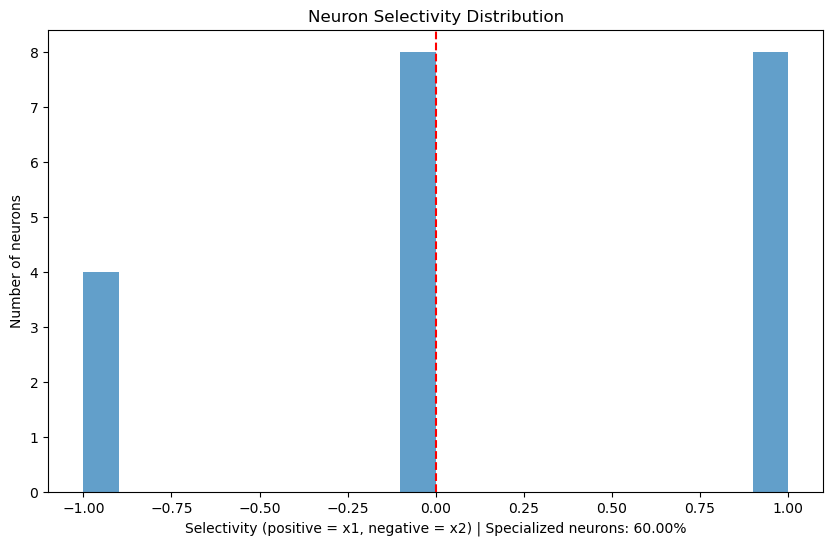

{'between_distance': 7.052892208099365, 'within_variance': 0.4852455258369446, 'separation_ratio': 10.124800682067871, 'specialized_score': 0.6000000238418579}


<Figure size 640x480 with 0 Axes>

In [101]:
from src.ce_exp import * 

# visualize_representations(mlp, valset, batch_size=32)
# visualize_representations_umap(mlp, valset, batch_size=32)
# visualize_representations_tsne(mlp, valset, batch_size=32)
separation_metrics = measure_separation(mlp, valset, batch_size=32)
specialized_score = neuron_specialization(mlp, valset, batch_size=32, save_path="logs/exp_a4_neuron_specialization.png")
separation_metrics['specialized_score'] = specialized_score
print(separation_metrics)

In [ ]:
# GAPT + mixed training
# {'between_distance': 5.22913122177124, 'within_variance': 0.4222445487976074, 'separation_ratio': 8.047250747680664, 'specialized_score': 0.8500000238418579}
# mxied training 
# {'between_distance': 3.0924227237701416, 'within_variance': 0.6075154542922974, 'separation_ratio': 3.967529773712158, 'specialized_score': 0.800000011920929}
# {'between_distance': 3.2041711807250977, 'within_variance': 0.46971017122268677, 'separation_ratio': 4.675205707550049, 'specialized_score': 0.75}
# CE + MBE 
# {'between_distance': 7.052892208099365, 'within_variance': 0.4852455258369446, 'separation_ratio': 10.124800682067871, 'specialized_score': 0.6000000238418579}


# Maybe the forgetting alleviation occurs after both rep is formed, but with GAPT they are formed in a more separate way? 


In [5]:
from PIL import Image
import os

# Paths to the GIF files
gif1_path = 'logs/exp_a7_neuron_specialization.gif'
gif2_path = 'logs/exp_a8_neuron_specialization.gif'
output_path = 'logs/combined_neuron_specialization.gif'

# Load the GIFs
gif1 = Image.open(gif1_path)
gif2 = Image.open(gif2_path)

# Get the number of frames in each GIF
def get_frame_count(gif):
    frames = 0
    try:
        while True:
            gif.seek(frames)
            frames += 1
    except EOFError:
        pass
    gif.seek(0)  # Reset to first frame
    return frames

n_frames1 = get_frame_count(gif1)
n_frames2 = get_frame_count(gif2)

# Use the minimum number of frames between the two GIFs
n_frames = min(n_frames1, n_frames2)

# Create new frames by combining images side by side
combined_frames = []
for i in range(n_frames):
    # Get current frames
    gif1.seek(i)
    gif2.seek(i)
    frame1 = gif1.copy().convert('RGBA')
    frame2 = gif2.copy().convert('RGBA')
    
    # Create a new image with enough width for both frames
    width = frame1.width + frame2.width
    height = max(frame1.height, frame2.height)
    combined = Image.new('RGBA', (width, height))
    
    # Paste the frames side by side
    combined.paste(frame1, (0, 0))
    combined.paste(frame2, (frame1.width, 0))
    
    combined_frames.append(combined)

# Save the combined GIF
fps = 4  # Use the same FPS as in your original code
duration = int(1000 / fps)  # Convert fps to duration in ms
combined_frames[0].save(
    output_path,
    save_all=True,
    append_images=combined_frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)

print(f"Combined GIF saved to {output_path}")


Combined GIF saved to logs/combined_neuron_specialization.gif


In [2]:
import os 
import pickle 
from src.utils import plot_dual_metrics

log_dir = "logs"

plot_dual_metrics(loss_record, names=(f'l1_positive', f'l1_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_l1_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'mbe_positive', f'mbe_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_mbe_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'param_shift_cosine_similarity_positive', f'param_shift_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_param_shift_sim_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'rep_cosine_similarity_positive', f'rep_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_rep_sim_pos_neg.png"), same_scale=True)

# save loss record 
with open(os.path.join(log_dir, f"{exp_name}_loss_record.pkl"), "wb") as f: 
    pickle.dump(loss_record, f)

Plotting metrics: l1_positive and l1_negative...
Using same scale for both axes: [0.0262, 0.7365]
- Plot saved to logs/exp_a8_l1_pos_neg.png
Plotting metrics: mbe_positive and mbe_negative...
Using same scale for both axes: [0.0147, 0.3788]
- Plot saved to logs/exp_a8_mbe_pos_neg.png
Plotting metrics: param_shift_cosine_similarity_positive and param_shift_cosine_similarity_negative...
Using same scale for both axes: [-0.0295, 0.0295]
- Plot saved to logs/exp_a8_param_shift_sim_pos_neg.png
Plotting metrics: rep_cosine_similarity_positive and rep_cosine_similarity_negative...
Using same scale for both axes: [0.4110, 0.6349]
- Plot saved to logs/exp_a8_rep_sim_pos_neg.png


In [9]:
import os, glob 

log_dir = "logs"  # Change this to your directory path if needed

# Find all PNG files
png_files = glob.glob(os.path.join(log_dir, "*.png"))
exps = ["exp_a7", "exp_a8"]
png_files = [f for f in png_files if any(exp in f for exp in exps)]
png_files.sort()  # Sort them for consistent arrangement

idx = 3
png_files[idx::4]

['logs/exp_a7_rep_sim_pos_neg.png', 'logs/exp_a8_rep_sim_pos_neg.png']

In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
import glob

# Directory containing the plots
log_dir = "logs"  # Change this to your directory path if needed

# Find all PNG files
# png_files = glob.glob(os.path.join(log_dir, "*.png"))
# exps = ["exp_a1", "exp_a2"]
# png_files = [f for f in png_files if any(exp in f for exp in exps)]
# png_files.sort()  # Sort them for consistent arrangement
# idx = 3
png_files = png_files[idx::4]

if not png_files:
    print(f"No PNG files found in {log_dir}")
else:
    # Calculate grid size based on number of images
    n_images = len(png_files)
    n_cols = min(2, n_images)  # Maximum 3 columns
    n_rows = (n_images + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure and subplots
    fig = plt.figure(figsize=(n_cols * 6, n_rows * 5))
    
    # Add each image to the plot
    for i, png_file in enumerate(png_files):
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        
        # Read image
        img = imread(png_file)
        ax.imshow(img)
        
        # Set title from filename (cleaned up)
        basename = os.path.basename(png_file)
        title = basename.replace('.png', '').replace('_', ' ')
        ax.set_title(title)
        
        # Remove axes for cleaner look
        ax.axis('off')
    
    # Adjust spacing
    plt.tight_layout()
    
    # Save combined figure
    combined_path = os.path.join(log_dir, "combined_plots.png")
    plt.savefig(combined_path, dpi=150, bbox_inches='tight')
    print(f"Combined plot saved at: {combined_path}")
    
    # Show the figure
    plt.show()

NameError: name 'png_files' is not defined

In [46]:
from src.ce_exp import * 

# ---- Natural ordered training ---- 

in_dim, hidden_dim, out_dim = 10, 20, 10 
data_size = 1000 
load_init = True
load_shift = True
exp_name = "exp_b2"
mod = "mix"
switch_phase = True

# Model initialization 
# ------------------------------------------------------------
mlp = SimpleModel(in_dim, hidden_dim, out_dim) # can we store a 'fixed' initial param, and load it every time we run experiment? 
INIT_PARAMS_PATH = 'initial_mlp_params.pt'
if load_init: 
    mlp.load_state_dict(torch.load(INIT_PARAMS_PATH))  # Load fixed parameters
else: 
    torch.save(mlp.state_dict(), INIT_PARAMS_PATH)
    
# Load Original Parameters for comparison purpose
# ------------------------------------------------------------
mlp_original = SimpleModel(in_dim, hidden_dim, out_dim)
mlp_original.load_state_dict(torch.load(INIT_PARAMS_PATH))

# Build 'Conflicting' dataset
# ------------------------------------------------------------
PARAM_SHIFT_PATH = "param_shift.pkl"
if load_shift: 
    param_shift = load_param_shift(PARAM_SHIFT_PATH)
else: 
    param_shift = None 
trainset, valset, param_shift = build_dataset(500, 100, mlp, in_dim, param_shift)


# Different Learning approaches 
# ------------------------------------------------------------
# (a). Train with P samples, then N samples 
# Initialize optimizer
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)
epochs = 400
batch_size = 32
train_accumulation_steps = batch_size // 1
val_interval = 10
val_steps = 10
tol_spike_ratio = 0.5

# GAPT
# ------------------------------------------------------------
from src.gapt import GatedPhaseTransition
gapt = GatedPhaseTransition(p_m=125, p_a=75, tau_spike=0.1)
# ------------------------------------------------------------


# Train with positive samples first, then negative samples
# print("Training with positive samples first, then negative samples")
print("Training with positive samples")

loss_record = defaultdict(list)
running_mbe_avg = 0.0

# Positive samples training
epoch = 0 
while epoch < epochs: 
    group_name = decide_group_name(epoch, epochs, mod="negative->positive")
    if epoch % val_interval == 0: 
        val_loss, similarity_metrics = validate(mlp, mlp_original, param_shift, valset, val_steps)
        for name, value in val_loss.items(): 
            loss_record[name].append(value.item())
        for name, value in similarity_metrics.items(): 
            loss_record[name].append(value)
        log_str = build_log_str(epoch, epochs, mod, val_loss, similarity_metrics)
        print(log_str)
            
    for accum_step in range(train_accumulation_steps): 
        x_batch, y_batch = get_batch(trainset, group_name)
        optimizer.zero_grad()
        loss_dict = mlp.compute_loss(x_batch, y_batch)

        
        # if loss_dict["mbe"] >= (1 + tol_spike_ratio) * running_mbe_avg:
        if False:
            print(f"Skipping high MBE training (mbe: {loss_dict['mbe']}, running_mbe_avg: {running_mbe_avg})")
            running_mbe_avg = running_mbe_avg * 0.999 + loss_dict["mbe"] * 0.001
            continue
        
        # loss = gapt.step(loss_dict['l1'], 20.0 * loss_dict['mbe'], verbose=False)
        loss = loss_dict["l1"]

        loss.backward()
        running_mbe_avg = running_mbe_avg * 0.5 + loss_dict["mbe"] * 0.5

    epoch += 1
        

    optimizer.step()
    mlp.zero_grad(set_to_none=True)

- Dataset constructed with 600 positive & negative samples
Training with positive samples
 Epoch 1/400,  | l1 positive loss: 0.4899 | mbe positive loss: 0.1121 | param shift similarity positive : 0.0000 | rep similarity positive : 0.5466 | l1 negative loss: 0.4557 | mbe negative loss: 0.2537 | param shift similarity negative : 0.0000 | rep similarity negative : 0.6078
 Epoch 11/400,  | l1 positive loss: 0.5627 | mbe positive loss: 0.1240 | param shift similarity positive : -0.1501 | rep similarity positive : 0.5484 | l1 negative loss: 0.1753 | mbe negative loss: 0.1159 | param shift similarity negative : 0.1501 | rep similarity negative : 0.6224
 Epoch 21/400,  | l1 positive loss: 0.6160 | mbe positive loss: 0.1498 | param shift similarity positive : -0.1731 | rep similarity positive : 0.5854 | l1 negative loss: 0.1097 | mbe negative loss: 0.1585 | param shift similarity negative : 0.1731 | rep similarity negative : 0.4516
 Epoch 31/400,  | l1 positive loss: 0.6451 | mbe positive loss:

In [ ]:
# Base (Neg train)
# l1 neg: 0.016 | mbe neg: 0.26 | l1 pos: 0.74 | mbe pos: 0.11
# Skip high MBE training (rejection learning)
# l1 neg: 0.016 | mbe neg: 0.26 | l1 pos: 0.76 | mbe pos: 0.09

# 100 step Base
# l1 neg: 0.03 | mbe neg: 0.28 
# 100 step Rejection learning
# l1 neg: 0.03 | mbe neg: 0.30
# -> [Conclusion] Rejection learning is not beneficial in 'interleaved training'

# Neg -> Pos | base 
# l1 pos: 0.04 | mbe pos: 0.24 | l1 neg: 0.80 (0.63) | mbe neg: 0.15
# Neg -> Pos | reject learn (decay=0.01 for rejected case)
# l1 pos: 0.04 | mbe pos: 0.21 | l1 neg: 0.58 (0.78) | mbe neg: 0.28 
# Neg -> Pos | reject learn (decay=0.001 for rejected case)
# l1 pos: 0.05 | mbe pos: 0.19 | l1 neg: 0.60 (0.72) | mbe neg: 0.22
# [Conclusion] Rejection learning has no impact on catastrophic forgetting alleviation

'positive'

In [ ]:
loss_dict

dict_keys(['l1', 'mbe'])

In [ ]:
# Experiment (I). Positive dataset training --> increase in parameter shift similarity with positive param shift. 
# Experiment (II). 

In [ ]:
# Get weight in MLP param 

# Sample a bunch of input samples 

# 1. Data preparation 
# Design a "shift" in the param space 
# - Apply shift to param, use resulting model to get output (targets) for all inputs 
# - Revert that 'shift' (Or just rotate it with near 180 degree) to obtain 'negative samples'
# This would give us a pair of datasets, which is nagatively aligned with each other in its 'loss's gradient over parameter'
# loss should be simple L1 loss

# 2. Training
# - Train with A, then B. 
# - Train with B, then A. 
# - Interleaved Training (A->B->A->B... or even just mix A & B together etc ...)
# - PGS-enhanced MBE regularization (Algo 3.a)
# - PBRS (Algo 3.c)
# - Phase transition (Algo 3.b)


# 3. Evaluation
# 1. L1 loss
# 2. MBE loss 
# 3. Gradient conflicts? (Intermediate gradient conflict, if we could observe it after 'resolving conflicting' in compression phase would be nice)
